In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 2** - Mystery ML model

- Model takes two numbers as input and returns a log-likelihood score.
  - **Goal** - maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.

- **Method of tackling this problem** - Bayesian optimisation, which selects the next inputs based on what it has learned so far.
  - I will aim to balance exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

- **Process and thinking** - use probability of improvement (PI) to exploit the area around our current best discovery.


- **Input** - 2D array (10, 2)
- **Output** - 1D array (10, )
- **Optimization Goal** - Maximise


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_2\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_2\initial_outputs.npy')

### **Random Search**


- This is the fist simple method to get a query just to explore thorugh trial-and-error method to just get a guage of the space.


In [3]:
next_query = np.random.uniform(size = 2)
print(next_query)

[0.90004291 0.5248858 ]


### **Bayesian Optimisation** - More strategic approach


I create a noise assumption which is a standard 0.01 and I will play around with this as we move forward in the exploration stages.


In [18]:
noise_assumption = 0.01


In [19]:
kernel = RBF(length_scale=1.0)
model = GaussianProcessRegressor(
    kernel = kernel,
    alpha = noise_assumption,
    n_restarts_optimizer= 10 # do multiple initializations to avoid local minima,
)
model.fit(X, Y)

GaussianProcessRegressor(alpha=0.01, kernel=RBF(length_scale=1),
                         n_restarts_optimizer=10)

### **Acquisition Function** with Probability of Improvements (PI)


I used expected improvements here as it provides me with the likelihood of beating the current max by a signifiacnt margin, rather than continuously waiting to look at the magintude of the gain and adapt accordingly.


In [29]:
def probability_of_improvement(X, model, y_max, eta=0.05):
    mu, sigma = model.predict(X, return_std=True)
    mu = mu.reshape(-1,1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        z = (mu - y_max - eta) / sigma
        pi = norm.cdf(z)
        pi[sigma == 0.0] = 0.0
        
    return pi.ravel()

### **Expanded search** - large-scale random search (30,000 points)


In [30]:
y_max = np.max(Y)

# Creating 10,000 points to enhance the 2D grid search
x_grid = np.random.uniform(0, 1, size=(30000, 2))

# Evaluate the acquisition function at these points
pi_values = probability_of_improvement(x_grid, gp, y_max, eta=0.05)

# Identify the point with the highest improvements
best_idx = np.argmax(pi_values)
next_query = x_grid[best_idx]

print(f"\nNext query point suggested by PI acquisition function: [{next_query[0]:.6f}, {next_query[1]:.6f}]")


Next query point suggested by PI acquisition function: [0.925637, 0.890755]


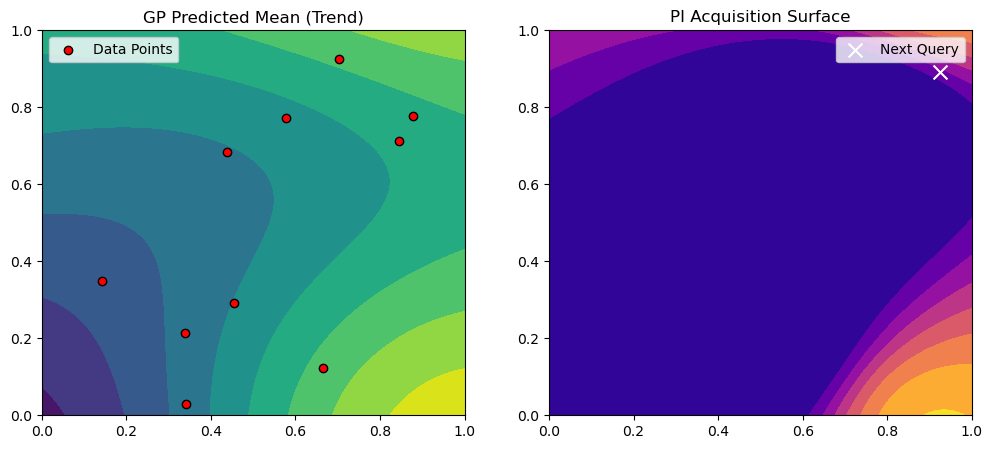


Next query point suggested by PI acquisition function: [0.925637, 0.890755]


In [31]:
# 1. Create a grid for the background colors
res = 100 # Increase to 100 for higher quality
x = np.linspace(0, 1, res)
y = np.linspace(0, 1, res)
X_mesh, Y_mesh = np.meshgrid(x, y)
grid = np.vstack([X_mesh.ravel(), Y_mesh.ravel()]).T

# 2. Get the values for the plots
mu_grid = model.predict(grid)
pi_grid = probability_of_improvement(grid, model, y_max, eta=0.05)

# 3. Create the two side-by-side plots
plt.figure(figsize=(12, 5))

# Plot 1: The Likelihood Trend
plt.subplot(1, 2, 1)
plt.contourf(X_mesh, Y_mesh, mu_grid.reshape(res, res), cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='black', label='Data Points')
plt.title('GP Predicted Mean (Trend)')
plt.legend()

# Plot 2: The PI Acquisition (The Decision)
plt.subplot(1, 2, 2)
plt.contourf(X_mesh, Y_mesh, pi_grid.reshape(res, res), cmap='plasma')
plt.scatter(next_query[0], next_query[1], c='white', marker='x', s=100, label='Next Query')
plt.title('PI Acquisition Surface')
plt.legend()

plt.show()

print(f"\nNext query point suggested by PI acquisition function: [{next_query[0]:.6f}, {next_query[1]:.6f}]")

### **Reasons for having a different input values for week 1 than what is shown here**


**Final Decision** - Due to inability of going through this process in time for week 1 submission I choose the input points which were purely based on exploration.

- **Hence the input for week 1** - [0.638512-0.01429]

- I will be using this thinking process and methodology moving forward into week 2.
